In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys
import cv2
from tqdm import tqdm
from PIL import Image
import time
import csv

sys.path.insert(0,'..')
print("ok")

ok


In [3]:
import torch
import torch.nn.functional as F
from transformers import AutoImageProcessor, AutoModel

from bundle_adjust.cam_utils import SatelliteImage
from bundle_adjust.feature_tracks.ft_opencv import opencv_detect_SIFT, opencv_match_SIFT
from bundle_adjust.feature_tracks.ft_lightglue import lightglue_matching

from bundle_adjust.feature_tracks.ft_pair_classifier import extract_DINO_embeddings


# ------------------------------------------------------------
# 1) SIFT baseline, same as before
# ------------------------------------------------------------
def compute_sift_match_counts(image_i, image_j):
    max_kps = 10000
    tracks_config = {"FT_kp_max": max_kps}
    features_i, _ = opencv_detect_SIFT(image_i.geotiff_path, tracks_config=tracks_config)
    features_j, _ = opencv_detect_SIFT(image_j.geotiff_path, tracks_config=tracks_config)
    _, _, n_matches_after_ransac = opencv_match_SIFT(
        features_i,
        features_j,
        dst_thr=0.8,
        ransac_thr=0.3,
        matcher="flann",
    )
    return n_matches_after_ransac

def compute_lightglue_match_counts(image_i, image_j, ransac_thr=0.3, max_kps=10000, R=None):
    """
    Returns:
        n_matches_raw: number of LightGlue matches before geometric filtering
        n_matches_final: number of matches after RANSAC filtering
    """
    tracks_config = {"FT_kp_max": max_kps}

    features_i, _ = opencv_detect_SIFT(image_i.geotiff_path, tracks_config=tracks_config)
    features_j, _ = opencv_detect_SIFT(image_j.geotiff_path, tracks_config=tracks_config)

    matches_ij, n_matches_raw, n_matches_final = lightglue_matching(
        features_i,
        features_j,
        ransac_thr=ransac_thr,
        max_matches=None,
        R=R,
    )
    return n_matches_raw, n_matches_final

# ------------------------------------------------------------
# 4) Pairwise cosine metrics
# ------------------------------------------------------------
def cosine_similarity_np(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def cosine_distance_np(a, b):
    # Smaller means more similar
    return float(1.0 - cosine_similarity_np(a, b))

# ------------------------------------------------------------
# 5) Main DINOv3 pipeline
# ------------------------------------------------------------
def pipeline_classifier_dino(
    images,
    pairs_to_match=None,
    model_name="facebook/dinov2-large",
    device=None,
):
    """
    Analogue of your SSIM pipeline, but using:
      - DINOv3 embedding per image
      - cosine similarity / cosine distance for pair scoring
    """
    start_time = time.time()

    n_images = len(images)

    if pairs_to_match is None:
        pairs_to_match = []
        for i in range(n_images):
            for j in range(i + 1, n_images):
                pairs_to_match.append((i, j))

    #pairs_to_match = pairs_to_match[:10]
    
    print(f"{len(pairs_to_match)} possible pairs")

    embeddings = extract_DINO_embeddings(images)

    rows = []
    for i, j in tqdm(pairs_to_match, desc="Scoring pairs"):
        cos_sim = cosine_similarity_np(embeddings[i], embeddings[j])
        cos_dist = 1.0 - cos_sim
        #n_matches = compute_sift_match_counts(images[i], images[j])
        _, n_matches = compute_lightglue_match_counts(images[i], images[j])

        rows.append({
            "id_0": int(i),
            "id_1": int(j),
            "cosine_similarity": float(cos_sim),
            "cosine_distance": float(cos_dist),
            "sift_matches_ransac": int(n_matches),
        })

    total_time = time.time() - start_time
    return rows, total_time


# ------------------------------------------------------------
# 6) Plot analogous to your SSIM plot
# ------------------------------------------------------------
def plot_cosine_distance_vs_sift_matches(rows, distance_threshold=0.20):
    """
    Smaller cosine distance => more similar.
    Keep pairs with cosine_distance <= threshold.
    """
    x = np.array([row["cosine_distance"] for row in rows], dtype=float)
    y = np.array([row["sift_matches_ransac"] for row in rows], dtype=float)

    kept_mask = x <= distance_threshold
    num_kept = int(np.sum(kept_mask))
    num_total = len(rows)

    plt.figure(figsize=(9, 6))

    # Background region for kept pairs
    x_min = min(0.0, float(np.min(x)) if len(x) > 0 else 0.0)
    plt.axvspan(x_min, distance_threshold, alpha=0.15)

    plt.scatter(x[~kept_mask], y[~kept_mask], alpha=0.7, label="Discarded pairs")
    plt.scatter(x[kept_mask], y[kept_mask], alpha=0.9, label="Kept pairs")

    plt.axvline(
        distance_threshold,
        linestyle="--",
        linewidth=2,
        label=f"Cosine distance threshold = {distance_threshold:.3f}",
    )

    plt.xlabel("Cosine distance between DINOv3 embeddings")
    plt.ylabel("Number of SIFT matches after RANSAC")
    plt.title("SIFT matches after RANSAC vs DINOv3 cosine distance")
    plt.grid(True)
    plt.legend()

    print(f"Kept pairs: {num_kept}/{num_total} ({100.0 * num_kept / max(1, num_total):.2f}%)")
    plt.show()

    return num_kept


def plot_cosine_similarity_vs_sift_matches(rows, similarity_threshold=0.80):
    """
    Equivalent alternative view:
    Larger cosine similarity => more similar.
    Keep pairs with cosine_similarity >= threshold.
    """
    x = np.array([row["cosine_similarity"] for row in rows], dtype=float)
    y = np.array([row["sift_matches_ransac"] for row in rows], dtype=float)

    kept_mask = x >= similarity_threshold
    num_kept = int(np.sum(kept_mask))
    num_total = len(rows)

    plt.figure(figsize=(9, 6))

    x_max = max(1.0, float(np.max(x)) if len(x) > 0 else 1.0)
    plt.axvspan(similarity_threshold, x_max, alpha=0.15)

    plt.scatter(x[~kept_mask], y[~kept_mask], alpha=0.7, label="Discarded pairs")
    plt.scatter(x[kept_mask], y[kept_mask], alpha=0.9, label="Kept pairs")

    plt.axvline(
        similarity_threshold,
        linestyle="--",
        linewidth=2,
        label=f"Cosine similarity threshold = {similarity_threshold:.3f}",
    )

    plt.xlabel("Cosine similarity between DINOv3 embeddings")
    plt.ylabel("Number of SIFT matches after RANSAC")
    plt.title("SIFT matches after RANSAC vs DINOv3 cosine similarity")
    plt.grid(True)
    plt.legend()

    print(f"Kept pairs: {num_kept}/{num_total} ({100.0 * num_kept / max(1, num_total):.2f}%)")
    plt.show()

    return num_kept


# ------------------------------------------------------------
# 7) CSV save/load helpers for rows
# ------------------------------------------------------------
def _to_python_scalar(x):
    """
    Convert numpy scalars to plain Python scalars so CSV contains normal values,
    e.g. np.int64 -> int.
    """
    if isinstance(x, np.generic):
        return x.item()
    return x


def save_rows_to_csv(rows, csv_path):
    """
    Saves list[dict] -> CSV.

    Assumptions:
    - rows is a flat list of dicts
    - values are scalar-like (int/float/str/bool or numpy scalar versions of those)
    - np.int64 becomes a normal integer in the CSV
    """
    if len(rows) == 0:
        raise ValueError("rows is empty")

    fieldnames = list(rows[0].keys())

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for row in rows:
            clean_row = {k: _to_python_scalar(v) for k, v in row.items()}
            writer.writerow(clean_row)


def load_rows_from_csv(csv_path, schema=None):
    """
    Reads CSV back into list[dict].

    Parameters
    ----------
    schema : dict or None
        Optional mapping column_name -> callable, e.g.
        {
            "id_0": int,
            "id_1": int,
            "cosine_similarity": float,
            "cosine_distance": float,
            "sift_matches_ransac": int,
        }

    Returns
    -------
    rows : list[dict]
    """
    rows = []
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if schema is not None:
                parsed = {}
                for k, v in row.items():
                    if k in schema and v != "":
                        parsed[k] = schema[k](v)
                    else:
                        parsed[k] = v
                row = parsed
            rows.append(row)

    return rows

861 possible pairs


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!
Scoring pairs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 861/861 [45:20<00:00,  3.16s/it]


Computed in 2728.00 s
Kept pairs: 744/861 (86.41%)


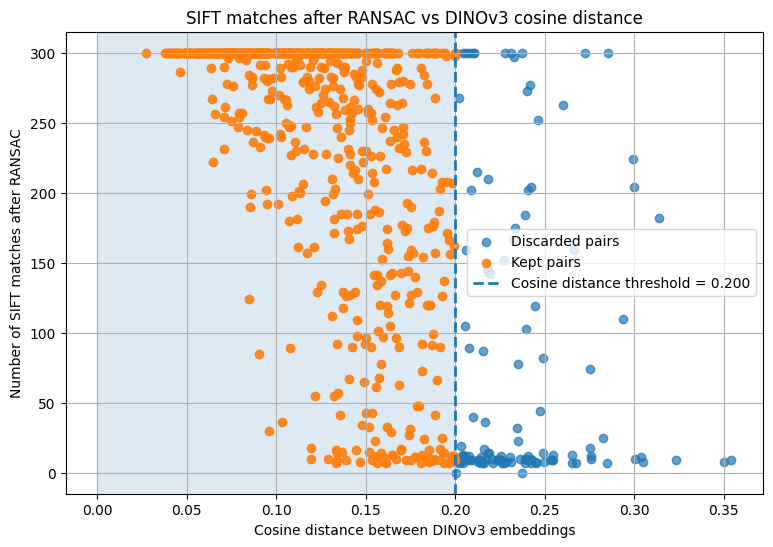

Kept pairs: 744/861 (86.41%)


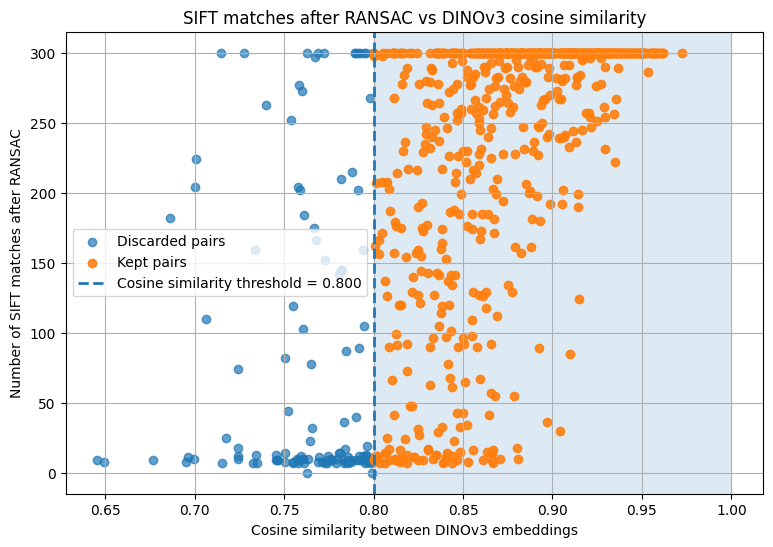

744

In [4]:
IMAGES_TO_IGNORE = {
    "JAX": ["6", "8", "9"],
    "UCSD": ["30", "31", "7"],
    "OMA": ["12"]
}

aoi_id = "OMA_177"
img_dir = "/home/roger/sat-bundleadjust_github/logs/OMA_177/images"

myimages = sorted(glob.glob(f"{img_dir}/*.tif"))

input_images = [SatelliteImage(p, None) for p in myimages]

rows, total_time = pipeline_classifier_dino(
    input_images,
    model_name="facebook/dinov2-large", #"facebook/dinov3-vitl16-pretrain-sat493m",
)

print(f"Computed in {total_time:.2f} s")

plot_cosine_distance_vs_sift_matches(rows, distance_threshold=0.20)
# or
plot_cosine_similarity_vs_sift_matches(rows, similarity_threshold=0.80)

In [17]:
csv_path = "/home/roger/BundleAdjustementClassifier/DATA/dinov2_vs_lightglue.csv"
save_rows_to_csv(rows, csv_path)
rows_ssim_vs_sift = load_rows_from_csv(csv_path)
print(f"Computed in {total_time:.2f} s")

Computed in 986.33 s
